# Handwriting imagery of simple vowels: a, o, e, i, u, ü

In [19]:
import math
import copy
import gdown
import random
import scipy.io
import os
import mne
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from scipy.stats import zscore 
# Torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from sklearn.model_selection import KFold
# Scikit-Learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Load handwriting imagery data

In [2]:
raw_data_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID' # Original data path: The folder contains data and events for all sessions
cleaned_data_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session'  #  Save the data with the "_T" suffix. Specifically, the data from session 1 will be used as the training set. 
files = os.listdir(raw_data_folder)   
filtered_files = [file for file in files if file.endswith('T.bdf')]  #Load data ending with T.bdf
#print(files)
#print(filtered_files)
# Iterating through filtered files 
for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)  # File path and file name
    # Reading raw data
    raw = mne.io.read_raw_bdf(file_path, preload=True)
   # print(raw)
   # High Pass Filtering 4-40 Hz
    raw.filter(l_freq=1, h_freq=40, fir_design='firwin') # fir_design='firwin'  band-pass filtering
    raw.notch_filter(freqs=50)
     # Saving the modified raw data to a file with .fif suffix
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif') # Save the data from session 1 in .fif format to a folder
    raw.save(new_file_path, overwrite=True)  

Extracting EDF parameters from F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID\A01T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4003999  =      0.000 ...  4003.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.5s


Writing F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session\A01T.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_24292\431976001.py:18: RuntimeWarning: This filename (F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session\A01T.fif
[done]


Event labels "1", "2", "3", "4", and "5" represent the five task strokes: horizontal, vertical, dot, right-falling, and folded strokes, respectively

# Create the data events and event_id without directly using mne.events_from_annotations to read events

In [3]:
# Suppose there are N subjects, an event should be created for each subject respectively 
# Assuming each row is formatted as [time point, event type] to obtain event information
events_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID'
files = os.listdir(events_folder)
filtered_files = [file for file in files if file.endswith('T_Event.txt')]  # The events of Session 1 as the training dataset, where "T" represents the events of the training data
print (filtered_files)
subject_events = {}

# Iterate through all event files and store the event information in a dictionary. This part mainly constructs the events
for file in filtered_files:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])
    events = np.array(events)
    subject_name = os.path.splitext(file)[0]  # Extract the file name, remove the extension, and use it as the subject name
    subject_events[subject_name] = events  # Store the events in a dictionary with subject_name as the key

# cleaned_data_folder = r'F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session'
fif_files = ['A01T.fif'] # The .fif data file of the target subject is placed here
all_subjects_data_T = []
all_subjects_labels_T = []

# Iterate through all .fif files and create epochs
for idx, fif_file in enumerate(fif_files):
    fif_file_path = os.path.join(cleaned_data_folder, fif_file)

    # Read. fif file
    raw = mne.io.read_raw_fif(fif_file_path, preload=True)
     # Delete Status channel
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    # Perform bad channel interpolation. The electrodes that need interpolation were identified by plotting and observing in MATLAB EEGLAB
    #raw.info["bads"] = ["T7"]  # Manually mark bad leads
    #raw.set_montage("standard_1020")  # Set electrode position
    # 2. Perform interpolation
    #raw_interpolated = raw.copy().interpolate_bads(reset_bads=True)
    
    # Obtain sampling frequency
    sfreq = raw.info["sfreq"]
    # Obtain event information of the current subject
    subject_name = os.path.splitext(fif_file)[0] + '_Event'
    print(subject_name)
    events = subject_events[subject_name]

    # creat epochs
    tmin=0
    tmax=4-1/sfreq  # The task-based paradigm design has a duration of 4 seconds   
    event_id = dict({'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6})
    epochs = mne.Epochs(raw, events, event_id, tmin, tmax, reject=None, baseline=None, preload=True) 
    # Downsampling to 250Hz
    epochs_resampled = epochs.copy().resample(250, npad="auto") 
    # Obtain epoch data and labels
    first_session_data = epochs_resampled.get_data(copy=True)  # Obtain data in the format of time*channel*trial 
    first_session_labels = epochs_resampled.events[:, -1]  #  trial *1
    
    # Process using Z-score standardization 
    #first_session_data_zscored = zscore(first_session_data, axis=-1)
    # Store the data and labels in a list
    all_subjects_data_T.append(first_session_data)
    all_subjects_labels_T.append(first_session_labels)
    print(first_session_data.shape)

['A01T_Event.txt']
Opening raw data file F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session\A01T.fif...
Isotrak not found
    Range : 0 ... 4003999 =      0.000 ...  4003.999 secs
Ready.
Reading 0 ... 4003999  =      0.000 ...  4003.999 secs...


C:\Users\fan\AppData\Local\Temp\ipykernel_24292\1223477777.py:31: RuntimeWarning: This filename (F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\First_Session\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file_path, preload=True)


A01T_Event
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 240 events and 4000 original time points ...
0 bad epochs dropped
(240, 32, 1000)


In [4]:
print(all_subjects_labels_T[0])

[1 2 3 6 4 5 6 5 2 4 3 1 6 1 4 5 2 3 5 2 3 1 4 6 1 4 6 3 5 2 1 5 6 4 3 2 1
 3 6 4 2 5 3 1 2 5 6 4 5 3 2 4 6 1 6 1 4 5 2 3 2 4 5 1 6 3 1 4 5 6 3 2 3 2
 1 5 4 6 5 6 1 3 2 4 5 1 2 6 3 4 2 4 6 3 1 5 6 3 2 5 4 1 6 3 1 2 5 4 1 2 4
 3 6 5 6 5 4 2 3 1 6 5 1 2 4 3 5 1 6 2 4 3 4 5 1 3 6 2 6 1 2 4 5 3 6 5 4 3
 2 1 3 6 4 2 1 5 6 4 1 2 5 3 2 6 4 1 3 5 2 4 5 6 1 3 4 5 1 2 3 6 4 2 6 5 3
 1 2 3 5 1 4 6 2 4 1 6 5 3 4 5 2 3 6 1 4 2 5 3 1 6 5 3 4 1 6 2 4 5 2 3 1 6
 1 4 3 6 5 2 5 3 4 6 2 1 5 4 6 1 3 2]


# Use Session 2 as the test set

In [5]:
raw_data_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID'  # Original data path
cleaned_data_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session'
files = os.listdir(raw_data_folder)   
filtered_files = [file for file in files if file.endswith('E.bdf')]  # Read data files ending with .bdf
#print(files)
#print(filtered_files)
# Iterating through filtered files 
for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)  
    # Reading raw data
    raw = mne.io.read_raw_bdf(file_path, preload=True)
   # print(raw)
   # High Pass Filtering 4-40 Hz
    raw.filter(l_freq=1, h_freq=40, fir_design='firwin')
    raw.notch_filter(freqs=50)
     # Saving the modified raw data to a file with .fif suffix
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True) 

Extracting EDF parameters from F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID\A01E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3649999  =      0.000 ...  3649.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Writing F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session\A01E.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_24292\3412212883.py:18: RuntimeWarning: This filename (F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session\A01E.fif
[done]


For session 2, create data events and event_ids without directly reading data using MNE

In [6]:
# Following the same logic as Session 1, if there are N subjects, an event should be created for each subject respectively
events_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Event_&_ID'
files = os.listdir(events_folder)
filtered_files = [file for file in files if file.endswith('E_Event.txt')]
print (filtered_files)
subject_events = {}

# Iterate through all event files and store the event information in a dictionary. This part mainly focuses on constructing the events
for file in filtered_files:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])
    events = np.array(events)
    subject_name = os.path.splitext(file)[0]  
    subject_events[subject_name] = events  

cleaned_data_folder = r'F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session'
fif_files = ['A01E.fif']

all_subjects_data_E = []
all_subjects_labels_E = []

# Iterate through all .fif files and create epochs
for idx, fif_file in enumerate(fif_files):
    fif_file_path = os.path.join(cleaned_data_folder, fif_file)

   # Read. fif file 
    raw = mne.io.read_raw_fif(fif_file_path, preload=True)
   # Delete Status channel
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    # Get the event information of the current subject
    subject_name = os.path.splitext(fif_file)[0] + '_Event'
    events = subject_events[subject_name]

    # 创建 epochs
    tmin=0
    tmax=4-1/sfreq  #  The task state duration in the paradigm design is 4 seconds
    event_id = dict({'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6})
    epochs = mne.Epochs(raw, events, event_id, tmin, tmax, reject=None, baseline=None, preload=True)
    epochs_resampled = epochs.copy().resample(250, npad="auto")
    # Obtain the epochs data and labels
    second_session_data = epochs_resampled.get_data(copy=True)
    second_session_labels =epochs_resampled.events[:, -1]
    # Process using Z-score standardization
    #second_session_data_zscored = zscore(second_session_data, axis=-1)
    all_subjects_data_E.append(second_session_data)
    all_subjects_labels_E.append(second_session_labels)

    print(second_session_data.shape)
    print(raw.info.ch_names) 

['A01E_Event.txt']
Opening raw data file F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session\A01E.fif...
Isotrak not found
    Range : 0 ... 3649999 =      0.000 ...  3649.999 secs
Ready.
Reading 0 ... 3649999  =      0.000 ...  3649.999 secs...


C:\Users\fan\AppData\Local\Temp\ipykernel_24292\2077306756.py:31: RuntimeWarning: This filename (F:\HI-EEG_BIDS\code\Hand_Writing_Imagery_SV_Data\Second_Session\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file_path, preload=True)


Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 240 events and 4000 original time points ...
0 bad epochs dropped
(240, 32, 1000)
['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'Cz', 'C3', 'C4', 'T7', 'T8', 'CP1', 'CP2', 'CP5', 'CP6', 'Pz', 'P3', 'P4', 'P7', 'P8', 'PO3', 'PO4', 'Oz', 'O1', 'O2']


In [7]:
print(second_session_data.shape)

(240, 32, 1000)


Data partitioning to make it suitable as input for CNN. Training method settings: use session 1 as the training set and session 2 as the test set, and perform five-fold cross-validation on the training set

In [8]:
## Data indices range from 0 to N and can be adjusted according to subsequent data additions
# Set up the device and loss function：   
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Loss Function
criterion = nn.CrossEntropyLoss()   #nn.CrossEntropyLoss 

# Normalize the labels and data, performed separately for each subject
# Initialize a new dataset list
normalized_all_subjects_data_T = []  
normalized_all_subjects_labels_T = []
normalized_all_subjects_data_E = []
normalized_all_subjects_labels_E = []

for i in range(1): 
    # Normalize features and use Session 1 as the training dataset
    X_train_normalized = (all_subjects_data_T[i] - np.mean(all_subjects_data_T[i])) / np.std(all_subjects_data_T[i])
    normalized_all_subjects_data_T.append(X_train_normalized)   #The list contains N subjects, and each array has a shape of (200, 32, 4000)
    # Normalize the labels
    y_train_normalized = all_subjects_labels_T[i] - np.min(all_subjects_labels_T[i])  #Normalize the labels by converting the class labels 1-5 to 0-4
    normalized_all_subjects_labels_T.append(y_train_normalized) 
   # pdb.set_trace() 
    print (normalized_all_subjects_data_T)
# Normalize the data for each subject in the test dataset
for i in range(1):
    # Normalize the labels
    X_test_normalized = (all_subjects_data_E[i] - np.mean(all_subjects_data_E[i])) / np.std(all_subjects_data_E[i]) #Normalization of the session 2 test set
    normalized_all_subjects_data_E.append(X_test_normalized)
    
    # Normalize the labels
    y_test_normalized = all_subjects_labels_E[i] - np.min(all_subjects_labels_E[i])
    normalized_all_subjects_labels_E.append(y_test_normalized)
    #print(all_subjects_labels_E)
   # print(normalized_all_subjects_labels_E)

[array([[[ 2.66093223e-01,  3.76295329e-01,  4.93729215e-01, ...,
         -3.25194372e+00, -3.33584072e+00, -3.41430595e+00],
        [-5.31677736e-01, -4.90361644e-01, -4.63094305e-01, ...,
         -2.55707458e+00, -2.62054379e+00, -2.85443793e+00],
        [-2.32227451e-01, -1.93074315e-01, -1.23022278e-01, ...,
         -3.10576626e-02, -1.13359884e-01, -2.48094916e-01],
        ...,
        [-1.21081831e-01,  7.73367395e-02,  3.53142226e-01, ...,
         -5.20358030e-01, -4.92834426e-01, -3.63782826e-01],
        [ 3.49202691e-02,  2.16967857e-01,  4.89182308e-01, ...,
         -4.44862619e-01, -4.24792247e-01, -2.92346949e-01],
        [-2.61711242e-01, -9.95511906e-02,  1.59264449e-01, ...,
         -5.75666202e-01, -5.90645426e-01, -4.74177099e-01]],

       [[-3.55587011e-01, -2.00359335e-01, -7.78768727e-02, ...,
          7.64540099e-01,  1.05960702e+00,  1.29413653e+00],
        [-2.52950119e-01, -1.61136838e-01, -7.16051166e-02, ...,
          7.22905714e-01,  1.04090185


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\fan\.conda\envs\myenv\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\fan\.conda\envs\myenv\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\fan\.conda\envs\myenv\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\fan\.conda\envs\myenv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\fan\

In [9]:
# print(normalized_all_subjects_labels_E)

In [10]:
# B=normalized_all_subjects_data_T[0]
# print(B.shape)
# print(normalized_all_subjects_data_E)

# Divide the data into training set and test set, and convert it to the input format of EEGNET

In [11]:
## The data of N subjects are assigned to training and testing respectively, that is, training and testing are performed on 9 subjects separately. The index of the subject data ranges from 0 to (N-1).
Subject=0  # subject 0-N-1 Subject selection
# Training set
Train_data=normalized_all_subjects_data_T[Subject]  # Subject 1's session1 T.bdf is used as the training dataset
Train_label=normalized_all_subjects_labels_T[Subject] #  The corresponding labels for the training set data
# Test set
Test_data=normalized_all_subjects_data_E[Subject]  # Session 2's T.bdf is used as the test dataset
Test_label=normalized_all_subjects_labels_E[Subject] #  The corresponding labels for the test set data
#print(Train_label)
##Convert to PyTorch tensors 
X_train = torch.Tensor(Train_data).unsqueeze(1).to(device)
y_train = torch.Tensor(Test_data).unsqueeze(1).to(device)  #It is assumed here that the model expects input in the shape of (batch_size, 1, channel, times)
X_label = torch.LongTensor(Train_label).to(device)
y_label = torch.LongTensor(Test_label).to(device)   
# print(y_label.shape)
## Create Tensor dataset  
train_dataset = TensorDataset(X_train, X_label) 
test_dataset = TensorDataset(y_train, y_label)

In [12]:
print(X_train.shape)
print(train_dataset)
# Obtain the tensors in the train_dataset
X_train_tensor, X_label_tensor = train_dataset.tensors

print(f"X_train tensor shape: {X_train_tensor.shape}")  # The dimensions of the feature tensor
print(f"X_label tensor shape: {X_label_tensor.shape}")  # The dimensions of the label tensor

y_train_tensor, y_label_tensor = test_dataset.tensors

# Check the dimensions of the feature and label tensors in the test set
print(f"y_train tensor shape: {y_train_tensor.shape}")
print(f"y_label tensor shape: {y_label_tensor.shape}")
print(f"y_train label: {X_label}")
print(f"y_label label: {y_label}")


torch.Size([240, 1, 32, 1000])
X_train tensor shape: torch.Size([240, 1, 32, 1000])
X_label tensor shape: torch.Size([240])
y_train tensor shape: torch.Size([240, 1, 32, 1000])
y_label tensor shape: torch.Size([240])
y_train label: tensor([0, 1, 2, 5, 3, 4, 5, 4, 1, 3, 2, 0, 5, 0, 3, 4, 1, 2, 4, 1, 2, 0, 3, 5,
        0, 3, 5, 2, 4, 1, 0, 4, 5, 3, 2, 1, 0, 2, 5, 3, 1, 4, 2, 0, 1, 4, 5, 3,
        4, 2, 1, 3, 5, 0, 5, 0, 3, 4, 1, 2, 1, 3, 4, 0, 5, 2, 0, 3, 4, 5, 2, 1,
        2, 1, 0, 4, 3, 5, 4, 5, 0, 2, 1, 3, 4, 0, 1, 5, 2, 3, 1, 3, 5, 2, 0, 4,
        5, 2, 1, 4, 3, 0, 5, 2, 0, 1, 4, 3, 0, 1, 3, 2, 5, 4, 5, 4, 3, 1, 2, 0,
        5, 4, 0, 1, 3, 2, 4, 0, 5, 1, 3, 2, 3, 4, 0, 2, 5, 1, 5, 0, 1, 3, 4, 2,
        5, 4, 3, 2, 1, 0, 2, 5, 3, 1, 0, 4, 5, 3, 0, 1, 4, 2, 1, 5, 3, 0, 2, 4,
        1, 3, 4, 5, 0, 2, 3, 4, 0, 1, 2, 5, 3, 1, 5, 4, 2, 0, 1, 2, 4, 0, 3, 5,
        1, 3, 0, 5, 4, 2, 3, 4, 1, 2, 5, 0, 3, 1, 4, 2, 0, 5, 4, 2, 3, 0, 5, 1,
        3, 4, 1, 2, 0, 5, 0, 3, 2, 5, 4, 1, 4, 2

In [13]:
## Train your EEGNet model using five-fold cross-validation on the session1 training dataset
# 1、This code sets up 5-fold cross-validation, splits the data accordingly for each fold, trains the EEGNet model on the training portion, and evaluates it on the validation portion 
# 2、You need to incorporate cross-validation logic into the train_model function. For each fold, you will use one of the splits as the validation set and the remaining splits as the training set
# 3、For each fold, you need to record metrics such as training loss and accuracy, and then calculate and output the average values of these metrics
class TrainModel:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def set_seed(self, seed):
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def train_model(self, model_class, dataset, learning_rate=0.001, batch_size=64, epochs=500, n_splits=5, weight_decay=0.015, seed=42, selection_metric='accuracy'):  # selection_metric可以是'loss'或'accuracy'
        self.set_seed(seed)  # Set the random seed before training starts
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        all_fold_accuracies = []
        all_fold_losses = []

        best_model_state = None
        best_epoch = 0  
        best_val_acc_at_best_loss = 0.0  # Record the accuracy corresponding to the best loss
        best_val_loss_at_best_acc = float('inf')  # Record the loss corresponding to the best accuracy

        if selection_metric == 'accuracy':
            overall_best_val_metric = 0.0  # For accuracy
        elif selection_metric == 'loss':
            overall_best_val_metric = float('inf')  # For loss
        else:
            raise ValueError("The selection_metric must be either 'accuracy' or 'loss'")

        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            print(f"Fold {fold+1}/{n_splits}")
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, pin_memory=False)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, pin_memory=False)

            model = model_class().to(self.device)
            criterion = nn.CrossEntropyLoss()

            # Here is the Adam optimizer with the added weight_decay parameter
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

            best_val_metric = 0.0 if selection_metric == 'accuracy' else float('inf')  # The best metric for the current fold

            # Store the training and validation loss and accuracy for each epoch 
            train_accuracies = []
            train_losses = []
            val_accuracies = []
            val_losses = []

            for epoch in range(epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                # Training Loop
                for inputs, labels in train_loader:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                epoch_loss = running_loss / len(train_loader.dataset)
                epoch_accuracy = correct / total

                # Store the training set loss and accuracy
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_accuracy)
                print(f"Epoch [{epoch+1}/{epochs}] - Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy*100:.2f}%")

                # Validation Loop
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs = inputs.to(self.device)
                        labels = labels.to(self.device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item() * inputs.size(0)
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader.dataset)
                val_accuracy = correct / total
                # Store the validation set loss and accuracy 
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)

                # Select the best metric
                current_val_metric = val_accuracy if selection_metric == 'accuracy' else val_loss
                if (selection_metric == 'accuracy' and current_val_metric > best_val_metric) or \
                   (selection_metric == 'loss' and current_val_metric < best_val_metric):
                    best_val_metric = current_val_metric
                    best_epoch = epoch + 1  # Update the best epoch

                # Update the overall best model 
                if (selection_metric == 'accuracy' and current_val_metric > overall_best_val_metric) or \
                   (selection_metric == 'loss' and current_val_metric < overall_best_val_metric):
                    overall_best_val_metric = current_val_metric
                    best_val_acc_at_best_loss = val_accuracy if selection_metric == 'loss' else best_val_acc_at_best_loss
                    best_val_loss_at_best_acc = val_loss if selection_metric == 'accuracy' else best_val_loss_at_best_acc
                    best_model_state = model.state_dict()

                print(f"Epoch [{epoch+1}/{epochs}] - Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy*100:.2f}%")
            # Print the best results of the current fold after each fold ends
            best_val_metric_display = best_val_metric * 100 if selection_metric == 'accuracy' else best_val_metric
            metric_name = "Accuracy" if selection_metric == 'accuracy' else "Loss"
            print(f"Best Validation {metric_name} for Fold {fold+1}: {best_val_metric_display:.2f}%{'%' if selection_metric == 'accuracy' else ''}")
            print(f"Validation Loss for Fold {fold+1}: {val_loss:.4f}")

            all_fold_accuracies.append(val_accuracy if selection_metric == 'accuracy' else best_val_metric)
            all_fold_losses.append(val_loss)

            # Plot the training and validation accuracy and loss curves for the current fold
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
            plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title(f'Fold {fold+1} - Loss')
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
            plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy')
            plt.title(f'Fold {fold+1} - Accuracy')
            plt.legend()

            plt.show()

        average_val_accuracy = sum(all_fold_accuracies) / n_splits if selection_metric == 'accuracy' else sum(all_fold_losses) / n_splits
        metric_label = "Validation Accuracy" if selection_metric == 'accuracy' else "Validation Loss"
        print(f"Average {metric_label}: {average_val_accuracy:.2f}%{'%' if selection_metric == 'accuracy' else ''}")

        print(f"Best {selection_metric} achieved at epoch {best_epoch}")
        if selection_metric == 'loss':
            print(f"Best Validation Loss: {overall_best_val_metric:.4f} with Validation Accuracy: {best_val_acc_at_best_loss * 100:.2f}%")
        else:
            #print(f"Best Validation Accuracy: {overall_best_val_metric * 100:.2f}% with Validation Loss: {best_val_loss_at_best_acc:.4f}")
            print(f"Best Validation Accuracy: {overall_best_val_metric * 100:.2f}% with Validation Loss: {best_val_loss_at_best_acc:.4f}")


        final_model = model_class().to(self.device)
        final_model.load_state_dict(best_model_state)
        return final_model

In [14]:
from matplotlib import rcParams  
class EvalModel():
    def __init__(self, model):  # Class initialization method  
        self.model = model.to(device)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    def test_model(self, test_dataset):  # Test the model
        self.model.eval()  # self.model.eval()：Set the model to evaluation mode
        correct = 0
        total = 0
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():  
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs) 
                _, predicted = torch.max(outputs.data, 1)   
                total += labels.size(0)
                correct += (predicted == labels).sum().item()  

        accuracy = (correct / total) * 100         # Calculate and return the test accuracy
        print("/------------------------------/")
        print(f"Test Accuracy: {accuracy:.2f}%")
        print("/------------------------------/")

        return accuracy

    def plot_confusion_matrix(self, test_dataset, classes):
        #  Times New Roman
        rcParams['font.family'] = 'Times New Roman'
        # Set Chinese font 
       #rcParams['font.family'] = 'Microsoft YaHei'
        #rcParams['axes.unicode_minus'] = False 
        self.model.eval()
        y_pred = []
        y_true = []
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                y_pred.append(predicted.item())
                y_true.append(labels.item())
        
        cf_matrix = confusion_matrix(y_true, y_pred)
        row_sums = cf_matrix.sum(axis=1)
        row_sums[row_sums == 0] = 1e-10  # Avoid division by zero
        cf_matrix = cf_matrix.astype('float') / row_sums[:, np.newaxis]

        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)

        # Check for NaNs
        #print("Confusion Matrix Values:\n", df_cm)

        # Visualization Settings
        fig, ax = plt.subplots(figsize=(12, 10))  # Canvas size setting
        cax = ax.imshow(cf_matrix, cmap="Blues", vmin=0, vmax=1.0)
        cbar = fig.colorbar(cax)

        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Add numbers to each cell, with the font color adjusted according to the value 
        for i in range(len(classes)):
            for j in range(len(classes)):
                # Judge the size of the number and adjust the font color
                font_color = "white" if cf_matrix[i, j] >= 0.5 else "black"
                ax.text(j, i, f"{cf_matrix[i, j]:.3f}",
                        ha="center", va="center", color=font_color, fontsize=16, fontweight='bold')

        # Set the title
        plt.title('Confusion Matrix', fontsize=24)

        # Rotate x-axis labels
        plt.xticks(rotation=0, ha="right", fontsize=16)  # The italic amplitude of the x-axis characters 
        plt.yticks(fontsize=16)

        # Increase the thickness of the border line
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

        # Set the thickness of the border line
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)

        # Set axis labels
        plt.xlabel('Predicted Labels', fontsize=18)
        plt.ylabel('True Labels', fontsize=18)

        # Adjust the font size of the numbers on the color bar to match that of the numbers in the heatmap
        cbar.ax.tick_params(labelsize=16)  

        # Adjust the border width of the color bar to match that of the confusion matrix
        cbar.ax.spines['top'].set_linewidth(2)  
        cbar.ax.spines['right'].set_linewidth(2)
        cbar.ax.spines['bottom'].set_linewidth(2)
        cbar.ax.spines['left'].set_linewidth(2)

        # Set the border color of the color bar
        cbar.outline.set_visible(True) 
        cbar.outline.set_linewidth(2)  
        cbar.outline.set_edgecolor('black') 

        # Set the width of the tick lines for the x and y axes
        ax.tick_params(axis='both', width=2)  

        # Set the tick line width of the color bar
        cbar.ax.tick_params(width=2)  

        # Auto-adjust the layout to prevent labels from being truncated
        plt.tight_layout()
        plt.savefig('confusion_matrix_model.png', dpi=300, bbox_inches='tight')
        plt.show()


# EEGNet Model

In [15]:
# The neural network model of EEGNetModel
class EEGNetModel(nn.Module): # EEGNET-8,2
    def __init__(self, chans=32, classes=6, time_points=1000, temp_kernel=25,   
                 f1=8, f2=16, d=2, pk1=16, pk2=8, dropout_rate=0.5, max_norm1=1, max_norm2=1):
        super(EEGNetModel, self).__init__() 
        # Calculating FC input features
        linear_size = (time_points//(pk1*pk2))*f2   
        # Temporal Filters
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding='same', bias=False),  
            nn.BatchNorm2d(f1),                                               
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False), # Depthwise Conv   
            nn.BatchNorm2d(d * f1),
            nn.ELU(),                                              
            nn.AvgPool2d((1, pk1)),                               
            nn.Dropout(dropout_rate)                              
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16),  groups=f2, bias=False, padding='same'), # Separable Conv  
            nn.Conv2d(f2, f2, kernel_size=1, bias=False), # Pointwise Conv  
            nn.BatchNorm2d(f2),  # Batch Normalization
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate)
        )
        self.flatten = nn.Flatten()         
        self.fc = nn.Linear(linear_size, classes) 

        # Apply max_norm constraint to the depthwise layer in block2
        self._apply_max_norm(self.block2[0], max_norm1) 

        # Apply max_norm constraint to the linear layer
        self._apply_max_norm(self.fc, max_norm2)

    def _apply_max_norm(self, layer, max_norm):     
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)   

    def forward(self, x):   
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

## Model Summery

In [16]:
input_size = (1, 32, 1000) # input_size: (1, 32, 1000)
eegnet_model = EEGNetModel().to(device)
summary(eegnet_model, input_size)  # summary()

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 8, 32, 1000]         --
|    └─Conv2d: 2-1                       [-1, 8, 32, 1000]         200
|    └─BatchNorm2d: 2-2                  [-1, 8, 32, 1000]         16
├─Sequential: 1-2                        [-1, 16, 1, 62]           --
|    └─Conv2d: 2-3                       [-1, 16, 1, 1000]         512
|    └─BatchNorm2d: 2-4                  [-1, 16, 1, 1000]         32
|    └─ELU: 2-5                          [-1, 16, 1, 1000]         --
|    └─AvgPool2d: 2-6                    [-1, 16, 1, 62]           --
|    └─Dropout: 2-7                      [-1, 16, 1, 62]           --
├─Sequential: 1-3                        [-1, 16, 1, 7]            --
|    └─Conv2d: 2-8                       [-1, 16, 1, 62]           256
|    └─Conv2d: 2-9                       [-1, 16, 1, 62]           256
|    └─BatchNorm2d: 2-10                 [-1, 16, 1, 62]           32
|    └─ELU:

C:\Users\fan\.conda\envs\myenv\lib\site-packages\torch\nn\modules\conv.py:459: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1004.)
  return F.conv2d(input, weight, bias, self.stride,


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 8, 32, 1000]         --
|    └─Conv2d: 2-1                       [-1, 8, 32, 1000]         200
|    └─BatchNorm2d: 2-2                  [-1, 8, 32, 1000]         16
├─Sequential: 1-2                        [-1, 16, 1, 62]           --
|    └─Conv2d: 2-3                       [-1, 16, 1, 1000]         512
|    └─BatchNorm2d: 2-4                  [-1, 16, 1, 1000]         32
|    └─ELU: 2-5                          [-1, 16, 1, 1000]         --
|    └─AvgPool2d: 2-6                    [-1, 16, 1, 62]           --
|    └─Dropout: 2-7                      [-1, 16, 1, 62]           --
├─Sequential: 1-3                        [-1, 16, 1, 7]            --
|    └─Conv2d: 2-8                       [-1, 16, 1, 62]           256
|    └─Conv2d: 2-9                       [-1, 16, 1, 62]           256
|    └─BatchNorm2d: 2-10                 [-1, 16, 1, 62]           32
|    └─ELU:

# Training Model

Fold 1/5
Epoch [1/1000] - Training Loss: 1.8283, Training Accuracy: 21.88%
Epoch [1/1000] - Validation Loss: 1.7921, Validation Accuracy: 16.67%
Epoch [2/1000] - Training Loss: 1.8190, Training Accuracy: 18.23%
Epoch [2/1000] - Validation Loss: 1.7920, Validation Accuracy: 16.67%
Epoch [3/1000] - Training Loss: 1.8214, Training Accuracy: 18.23%
Epoch [3/1000] - Validation Loss: 1.7921, Validation Accuracy: 20.83%
Epoch [4/1000] - Training Loss: 1.8338, Training Accuracy: 18.23%
Epoch [4/1000] - Validation Loss: 1.7925, Validation Accuracy: 20.83%
Epoch [5/1000] - Training Loss: 1.8215, Training Accuracy: 19.27%
Epoch [5/1000] - Validation Loss: 1.7934, Validation Accuracy: 22.92%
Epoch [6/1000] - Training Loss: 1.8368, Training Accuracy: 18.75%
Epoch [6/1000] - Validation Loss: 1.7946, Validation Accuracy: 20.83%
Epoch [7/1000] - Training Loss: 1.8024, Training Accuracy: 20.31%
Epoch [7/1000] - Validation Loss: 1.7960, Validation Accuracy: 20.83%
Epoch [8/1000] - Training Loss: 1.8314,

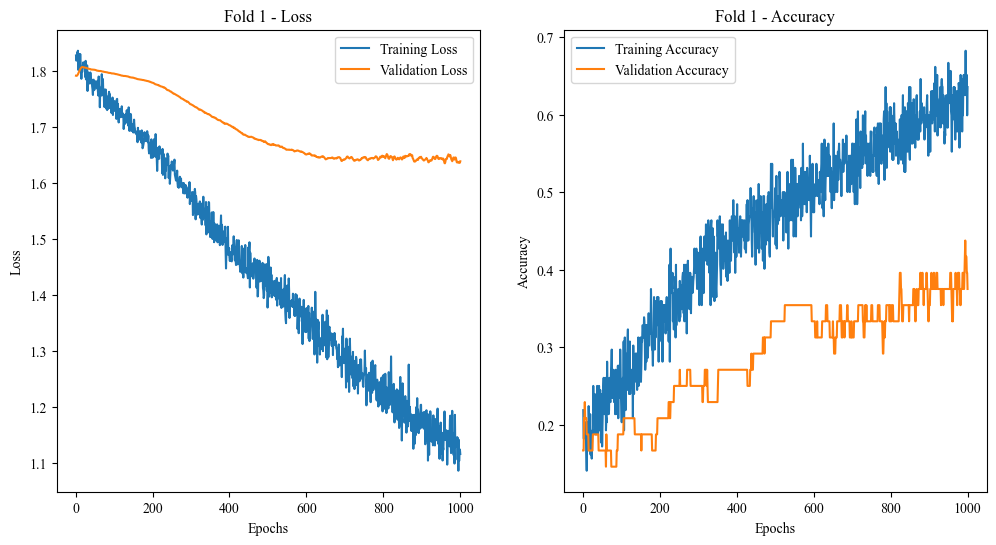

Fold 2/5
Epoch [1/1000] - Training Loss: 1.8131, Training Accuracy: 17.19%
Epoch [1/1000] - Validation Loss: 1.7897, Validation Accuracy: 14.58%
Epoch [2/1000] - Training Loss: 1.7955, Training Accuracy: 21.35%
Epoch [2/1000] - Validation Loss: 1.7884, Validation Accuracy: 12.50%
Epoch [3/1000] - Training Loss: 1.8146, Training Accuracy: 20.83%
Epoch [3/1000] - Validation Loss: 1.7866, Validation Accuracy: 12.50%
Epoch [4/1000] - Training Loss: 1.8643, Training Accuracy: 19.27%
Epoch [4/1000] - Validation Loss: 1.7841, Validation Accuracy: 12.50%
Epoch [5/1000] - Training Loss: 1.7874, Training Accuracy: 20.83%
Epoch [5/1000] - Validation Loss: 1.7811, Validation Accuracy: 14.58%
Epoch [6/1000] - Training Loss: 1.7816, Training Accuracy: 20.83%
Epoch [6/1000] - Validation Loss: 1.7776, Validation Accuracy: 20.83%
Epoch [7/1000] - Training Loss: 1.8192, Training Accuracy: 16.67%
Epoch [7/1000] - Validation Loss: 1.7736, Validation Accuracy: 18.75%
Epoch [8/1000] - Training Loss: 1.8264,

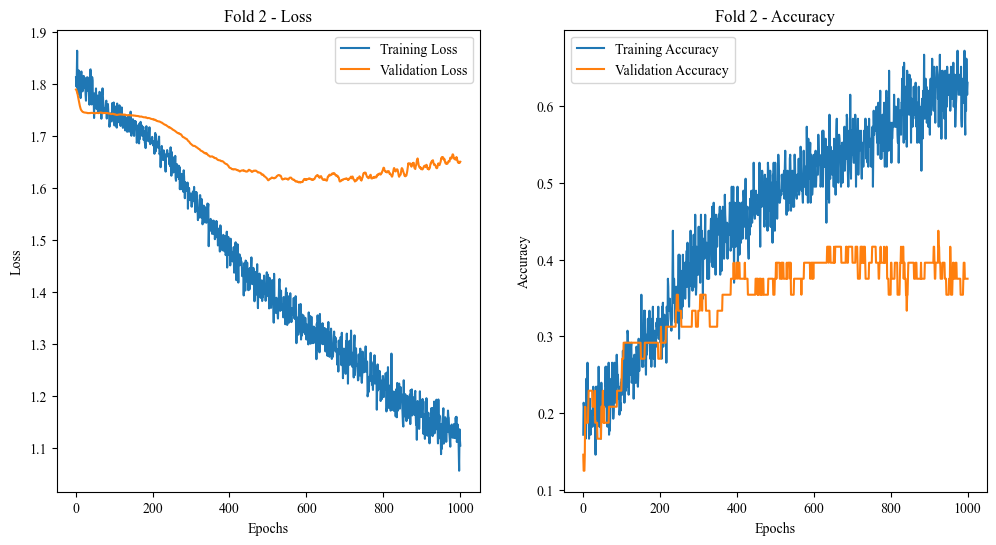

Fold 3/5
Epoch [1/1000] - Training Loss: 1.8147, Training Accuracy: 18.75%
Epoch [1/1000] - Validation Loss: 1.7952, Validation Accuracy: 16.67%
Epoch [2/1000] - Training Loss: 1.8295, Training Accuracy: 20.31%
Epoch [2/1000] - Validation Loss: 1.7944, Validation Accuracy: 14.58%
Epoch [3/1000] - Training Loss: 1.8189, Training Accuracy: 17.19%
Epoch [3/1000] - Validation Loss: 1.7937, Validation Accuracy: 12.50%
Epoch [4/1000] - Training Loss: 1.8327, Training Accuracy: 15.10%
Epoch [4/1000] - Validation Loss: 1.7931, Validation Accuracy: 10.42%
Epoch [5/1000] - Training Loss: 1.8347, Training Accuracy: 16.15%
Epoch [5/1000] - Validation Loss: 1.7924, Validation Accuracy: 12.50%
Epoch [6/1000] - Training Loss: 1.8338, Training Accuracy: 16.67%
Epoch [6/1000] - Validation Loss: 1.7920, Validation Accuracy: 10.42%
Epoch [7/1000] - Training Loss: 1.8284, Training Accuracy: 16.15%
Epoch [7/1000] - Validation Loss: 1.7918, Validation Accuracy: 12.50%
Epoch [8/1000] - Training Loss: 1.8131,

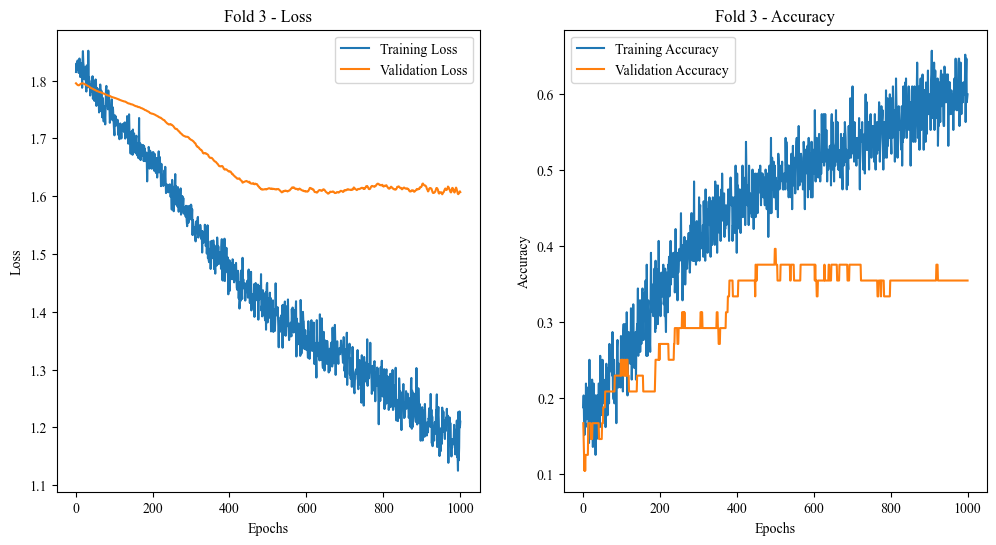

Fold 4/5
Epoch [1/1000] - Training Loss: 1.8450, Training Accuracy: 16.15%
Epoch [1/1000] - Validation Loss: 1.7973, Validation Accuracy: 16.67%
Epoch [2/1000] - Training Loss: 1.8369, Training Accuracy: 14.06%
Epoch [2/1000] - Validation Loss: 1.7970, Validation Accuracy: 14.58%
Epoch [3/1000] - Training Loss: 1.8537, Training Accuracy: 17.19%
Epoch [3/1000] - Validation Loss: 1.7966, Validation Accuracy: 18.75%
Epoch [4/1000] - Training Loss: 1.8221, Training Accuracy: 13.02%
Epoch [4/1000] - Validation Loss: 1.7963, Validation Accuracy: 14.58%
Epoch [5/1000] - Training Loss: 1.8240, Training Accuracy: 16.15%
Epoch [5/1000] - Validation Loss: 1.7961, Validation Accuracy: 16.67%
Epoch [6/1000] - Training Loss: 1.7975, Training Accuracy: 19.27%
Epoch [6/1000] - Validation Loss: 1.7958, Validation Accuracy: 18.75%
Epoch [7/1000] - Training Loss: 1.8334, Training Accuracy: 14.06%
Epoch [7/1000] - Validation Loss: 1.7960, Validation Accuracy: 18.75%
Epoch [8/1000] - Training Loss: 1.8165,

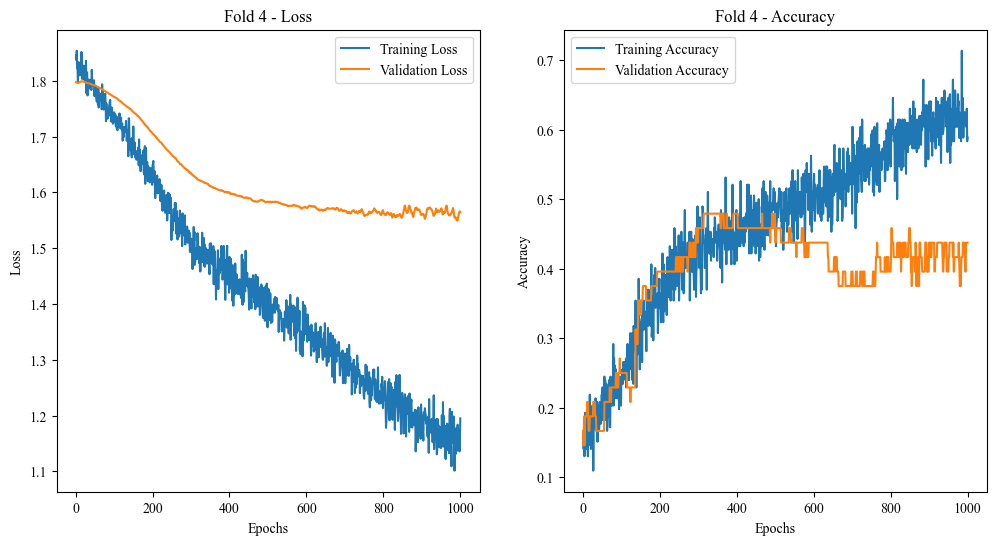

Fold 5/5
Epoch [1/1000] - Training Loss: 1.8128, Training Accuracy: 15.62%
Epoch [1/1000] - Validation Loss: 1.7972, Validation Accuracy: 12.50%
Epoch [2/1000] - Training Loss: 1.8252, Training Accuracy: 17.19%
Epoch [2/1000] - Validation Loss: 1.7990, Validation Accuracy: 12.50%
Epoch [3/1000] - Training Loss: 1.8091, Training Accuracy: 17.19%
Epoch [3/1000] - Validation Loss: 1.8013, Validation Accuracy: 12.50%
Epoch [4/1000] - Training Loss: 1.8459, Training Accuracy: 16.67%
Epoch [4/1000] - Validation Loss: 1.8039, Validation Accuracy: 16.67%
Epoch [5/1000] - Training Loss: 1.8353, Training Accuracy: 14.06%
Epoch [5/1000] - Validation Loss: 1.8068, Validation Accuracy: 12.50%
Epoch [6/1000] - Training Loss: 1.8210, Training Accuracy: 16.15%
Epoch [6/1000] - Validation Loss: 1.8099, Validation Accuracy: 10.42%
Epoch [7/1000] - Training Loss: 1.8189, Training Accuracy: 15.62%
Epoch [7/1000] - Validation Loss: 1.8132, Validation Accuracy: 10.42%
Epoch [8/1000] - Training Loss: 1.8219,

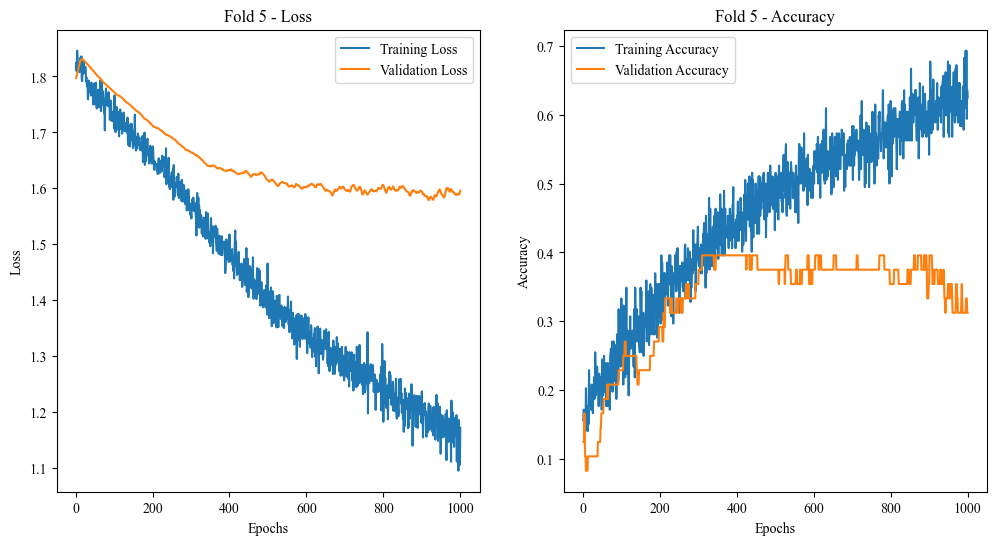

Average Validation Accuracy: 0.37%%
Best accuracy achieved at epoch 310
Best Validation Accuracy: 47.92% with Validation Loss: 1.6258


In [24]:
# Training Hyperparameters
EPOCHS =1000
BATCH_SIZE = 64  
LEARNING_RATE = 0.0001
N_splits=5
Weight_decay=0.075
#trainer = TrainModel() 
trainer=TrainModel()  
trained_eegnet_model = trainer.train_model(
    model_class=EEGNetModel,  
    dataset=train_dataset,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    n_splits=N_splits,
    weight_decay=Weight_decay
)
torch.save(trained_eegnet_model.state_dict(), 'eegnet_model.pth')

/------------------------------/
Test Accuracy: 38.33%
/------------------------------/


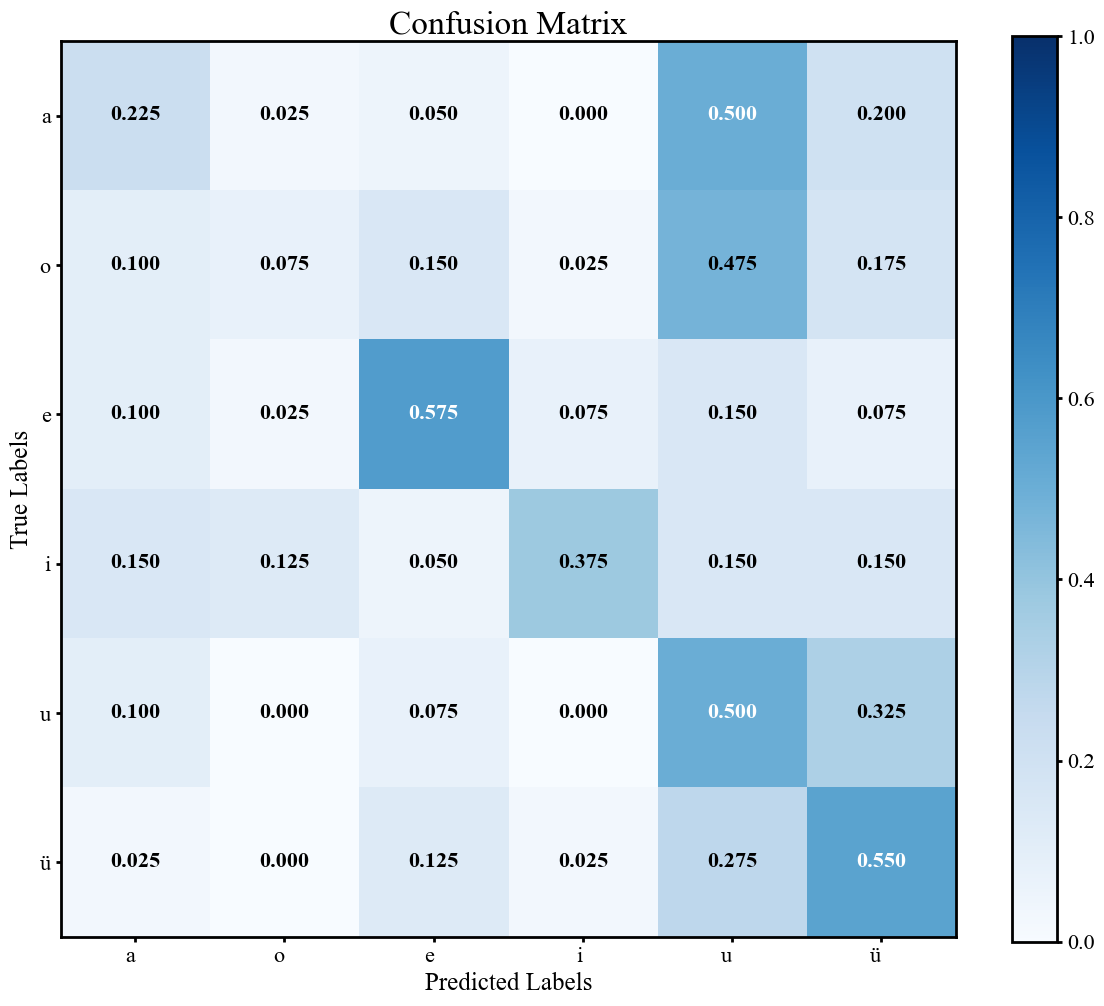

In [25]:
# Use the EvalModel class to evaluate the pre-trained EEGNet model
classes_list  = ['a', 'o', 'e', 'i', 'u', 'ü']    # Category labels: Pinyin monophthong names
#classes_list = ['一', '丨', '丿', '㇏', 'ㄥ']
eval_model = EvalModel(trained_eegnet_model)  
test_accuracy = eval_model.test_model(test_dataset)
eval_model.plot_confusion_matrix(test_dataset, classes_list)